# IA de prédiction de matchs de football (1X2 & Over/Under 2.5) — Google Colab

**Pipeline** : données (résultats + stats + Elo + cotes) → features sans fuite → modèles (Régression logistique, XGBoost, LightGBM) → probabilités calibrées → comparaison aux cotes → backtest financier (mise fixe, Kelly, Fibonacci).

**Données** : [Club-Football-Match-Data (xgabora)](https://github.com/xgabora/Club-Football-Match-Data-2000-2025) — ~239 000 matchs, 38 championnats, 2000 → saison en cours, construit à partir de football-data.co.uk (stats + cotes Bet365 et meilleures cotes du marché) et ClubElo. Mis à jour périodiquement.

**Avertissement** : aucune méthode n'est « sûre ». Ce notebook mesure honnêtement si un modèle bat le marché ; la plupart du temps, il ne le bat pas. Ne pariez jamais d'argent dont la perte vous gênerait.

`Exécution → Tout exécuter` (Runtime → Run all). Durée : ~3–6 min sur un runtime CPU gratuit ; aucun GPU nécessaire.

In [1]:
# 0. Installation / imports (lightgbm et xgboost sont déjà présents sur Colab)
!pip -q install lightgbm xgboost
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, brier_score_loss
import xgboost as xgb
import lightgbm as lgb
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
RNG = np.random.default_rng(42)

# ---- PARAMÈTRES -----------------------------------------------------------
DATA_URL = "https://raw.githubusercontent.com/xgabora/Club-Football-Match-Data-2000-2025/main/data/Matches.csv"
LEAGUES  = ["E0", "SP1", "I1", "D1", "F1"]   # Premier League, Liga, Serie A, Bundesliga, Ligue 1
FIRST_SEASON = 2006                          # stats de tirs complètes à partir de 2006/07
TRAIN_END, VALID_SEASON = 2021, 2022         # train ≤ 2021/22, validation 2022/23, test ≥ 2023/24
ROLL = 5                                     # fenêtre de forme récente

## 1. Chargement des données

In [2]:
raw = pd.read_csv(DATA_URL, parse_dates=["MatchDate"], low_memory=False)
print(raw.shape, "| du", raw.MatchDate.min().date(), "au", raw.MatchDate.max().date())

df = raw[raw.Division.isin(LEAGUES)].copy()
df["Season"] = np.where(df.MatchDate.dt.month >= 7, df.MatchDate.dt.year, df.MatchDate.dt.year - 1)
df = df[(df.Season >= FIRST_SEASON - 1)].dropna(subset=["FTResult", "FTHome", "FTAway"])
# ⚠ Les colonnes C_* (clusters) sont calculées à partir des stats DU match → fuite de données : on les supprime.
df = df.drop(columns=[c for c in df.columns if c.startswith("C_")])
df = df.sort_values(["MatchDate", "Division", "HomeTeam"]).reset_index(drop=True)
df["match_id"] = np.arange(len(df))
df["y"] = df.FTResult.map({"H": 0, "D": 1, "A": 2})
df["goals"] = df.FTHome + df.FTAway
df["over25"] = (df.goals > 2.5).astype(int)
print(len(df), "matchs retenus")
df[["Division","MatchDate","HomeTeam","AwayTeam","FTHome","FTAway","OddHome","OddDraw","OddAway","HomeElo","AwayElo"]].tail()

(238858, 48) | du 2000-07-28 au 2026-09-03
37741 matchs retenus


,Division,MatchDate,HomeTeam,AwayTeam,FTHome,FTAway,OddHome,OddDraw,OddAway,HomeElo,AwayElo
37736,I1,2026-08-31,Lecce,Roma,0.0,4.0,8.00,4.00,1.48,1613.52,1828.30
37737,SP1,2026-08-31,Barcelona,Vallecano,5.0,2.0,1.17,8.00,13.00,1967.92,1684.06
37738,SP1,2026-08-31,Osasuna,Getafe,1.0,0.0,2.20,3.00,3.75,1654.79,1662.89
37739,F1,2026-09-03,Toulouse,Lille,0.0,1.0,3.25,3.25,2.15,1654.07,1789.37
37740,SP1,2026-09-03,Sociedad,Celta,0.0,0.0,1.95,3.60,3.80,1663.97,1682.41


## 2. Analyse exploratoire : le point de départ
Avant tout modèle, on mesure : taux de base 1/X/2, buts, marge du bookmaker, précision et calibration du marché, rentabilité des stratégies « aveugles ». C'est la barre à franchir.

Taux de base : {'H': 0.442, 'A': 0.307, 'D': 0.252}
Buts/match : 2.77 | Over 2.5 : 52.5%


,n,dom,nul,ext,buts,over25
Division,,,,,,
D1,3681,0.446,0.249,0.306,3.048,0.588
E0,4580,0.444,0.237,0.318,2.803,0.538
F1,4255,0.441,0.254,0.306,2.689,0.505
I1,4580,0.421,0.259,0.320,2.724,0.520
SP1,4591,0.457,0.259,0.284,2.633,0.484


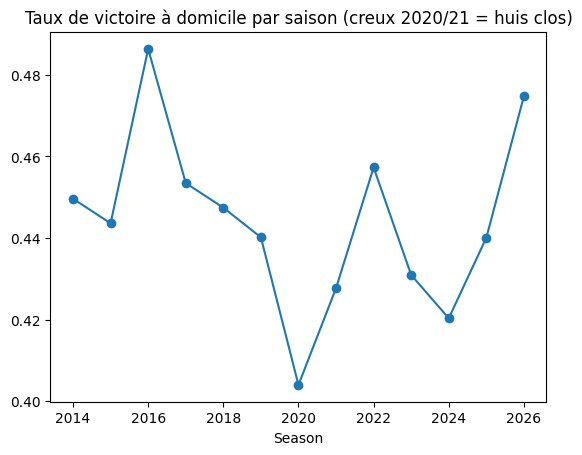

In [3]:
e = df[df.Season >= 2014]
print("Taux de base :", e.FTResult.value_counts(normalize=True).round(3).to_dict())
print("Buts/match : %.2f | Over 2.5 : %.1f%%" % (e.goals.mean(), 100 * e.over25.mean()))
summary = e.groupby("Division").agg(n=("y", "size"), dom=("y", lambda s: (s == 0).mean()),
                                    nul=("y", lambda s: (s == 1).mean()), ext=("y", lambda s: (s == 2).mean()),
                                    buts=("goals", "mean"), over25=("over25", "mean")).round(3)
display(summary)
e.groupby("Season").y.apply(lambda s: (s == 0).mean()).plot(marker="o", title="Taux de victoire à domicile par saison (creux 2020/21 = huis clos)"); plt.show()

In [4]:
def implied(odds_h, odds_d, odds_a):
    """Probabilités implicites dé-margées (normalisation proportionnelle)."""
    inv = np.c_[1 / odds_h, 1 / odds_d, 1 / odds_a]
    over = inv.sum(1, keepdims=True)
    return inv / over, over.ravel() - 1          # probas, marge

o = e.dropna(subset=["OddHome", "OddDraw", "OddAway"])
P_mkt, margin = implied(o.OddHome.values, o.OddDraw.values, o.OddAway.values)
print("Marge moyenne Bet365 1X2 : %.2f%%" % (100 * margin.mean()))
print("Marché (favori) — accuracy %.3f | log loss %.4f" % ((P_mkt.argmax(1) == o.y).mean(), log_loss(o.y, P_mkt)))
prior = np.bincount(o.y, minlength=3) / len(o)
print("Référence naïve (taux de base) — log loss %.4f" % log_loss(o.y, np.tile(prior, (len(o), 1))))

cal = pd.DataFrame({"p": P_mkt[:, 0], "obs": (o.y == 0).values})
cal["bin"] = pd.cut(cal.p, [0, .2, .3, .4, .5, .6, .7, .8, 1])
display(cal.groupby("bin").agg(n=("obs", "size"), proba_marche=("p", "mean"), frequence_reelle=("obs", "mean")).round(3))

def flat_roi(odds, won):
    return (np.sum(odds * won) - len(odds)) / len(odds)
for lab, k, col in [("Domicile", 0, "OddHome"), ("Nul", 1, "OddDraw"), ("Extérieur", 2, "OddAway")]:
    print(f"Parier toujours {lab:9s}: ROI Bet365 {100*flat_roi(o[col].values, o.y.values==k):+.1f}%  |  meilleure cote {100*flat_roi(o['Max'+col[3:]].values, o.y.values==k):+.1f}%")

Marge moyenne Bet365 1X2 : 4.74%
Marché (favori) — accuracy 0.538 | log loss 0.9675
Référence naïve (taux de base) — log loss 1.0706


,n,proba_marche,frequence_reelle
bin,,,
"(0.0, 0.2]",2162,0.143,0.139
"(0.2, 0.3]",2915,0.254,0.241
"(0.3, 0.4]",4296,0.354,0.340
"(0.4, 0.5]",4681,0.449,0.446
"(0.5, 0.6]",3220,0.549,0.558
"(0.6, 0.7]",2278,0.649,0.677
"(0.7, 0.8]",1444,0.747,0.756
"(0.8, 1.0]",689,0.843,0.862


Parier toujours Domicile : ROI Bet365 -5.7%  |  meilleure cote -1.4%
Parier toujours Nul      : ROI Bet365 -4.6%  |  meilleure cote +0.4%
Parier toujours Extérieur: ROI Bet365 -7.7%  |  meilleure cote -1.8%


## 3. Feature engineering (sans fuite de données)
Règle d'or : **chaque feature d'un match n'utilise que des informations connues avant le coup d'envoi**. Techniquement : table longue « une ligne par équipe et par match », tri chronologique, puis `shift(1)` avant toute moyenne mobile.

In [5]:
def to_long(d):
    base = ["match_id", "MatchDate", "Season", "Division"]
    h = d[base].copy(); a = d[base].copy()
    h["team"], h["opp"], h["is_home"] = d.HomeTeam, d.AwayTeam, 1
    a["team"], a["opp"], a["is_home"] = d.AwayTeam, d.HomeTeam, 0
    pairs = {"gf": ("FTHome", "FTAway"), "ga": ("FTAway", "FTHome"), "sh_f": ("HomeShots", "AwayShots"),
             "sh_a": ("AwayShots", "HomeShots"), "sot_f": ("HomeTarget", "AwayTarget"),
             "sot_a": ("AwayTarget", "HomeTarget"), "cor_f": ("HomeCorners", "AwayCorners"),
             "cor_a": ("AwayCorners", "HomeCorners")}
    for k, (hc, ac) in pairs.items():
        h[k], a[k] = d[hc].values, d[ac].values
    L = pd.concat([h, a], ignore_index=True)
    L["pts"] = np.select([L.gf > L.ga, L.gf == L.ga], [3, 1], 0).astype(float)
    L.loc[L.gf.isna(), "pts"] = np.nan                     # matchs futurs
    return L.sort_values(["team", "MatchDate", "match_id"]).reset_index(drop=True)

def team_features(L, n=ROLL):
    g = L.groupby("team", sort=False)
    stats = ["gf", "ga", "sh_f", "sh_a", "sot_f", "sot_a", "cor_f", "cor_a", "pts"]
    past = g[stats].shift(1)                               # ← la ligne du match lui-même est exclue
    F = pd.DataFrame(index=L.index)
    for s in stats:
        F[f"{s}_r{n}"] = past[s].groupby(L.team).transform(lambda x: x.rolling(n, min_periods=3).mean())
        F[f"{s}_ewm"] = past[s].groupby(L.team).transform(lambda x: x.ewm(span=10, min_periods=3).mean())
    F["pts_r10"] = past["pts"].groupby(L.team).transform(lambda x: x.rolling(10, min_periods=5).mean())
    # conversion : buts / tirs cadrés, sur 10 matchs
    gf10 = past["gf"].groupby(L.team).transform(lambda x: x.rolling(10, min_periods=5).sum())
    sot10 = past["sot_f"].groupby(L.team).transform(lambda x: x.rolling(10, min_periods=5).sum())
    F["conv_r10"] = gf10 / sot10.replace(0, np.nan)
    # forme spécifique domicile / extérieur
    gv = L.groupby(["team", "is_home"], sort=False)
    pv = gv[["pts", "gf", "ga"]].shift(1)
    for s in ["pts", "gf", "ga"]:
        F[f"{s}_venue_r{n}"] = pv[s].groupby([L.team, L.is_home]).transform(lambda x: x.rolling(n, min_periods=2).mean())
    # points par match depuis le début de saison
    ps = L.groupby(["team", "Season"], sort=False)["pts"].shift(1)
    F["ppg_season"] = ps.groupby([L.team, L.Season]).transform(lambda x: x.expanding().mean())
    F["n_played_season"] = ps.groupby([L.team, L.Season]).transform(lambda x: x.notna().cumsum())
    # repos (jours depuis le dernier match de championnat)
    F["rest_days"] = g.MatchDate.diff().dt.days.clip(upper=21)
    return pd.concat([L[["match_id", "team", "is_home"]], F], axis=1)

def h2h_feature(d, n=5):
    """Différence de buts moyenne des n dernières confrontations, du point de vue de l'équipe à domicile."""
    first = np.where(d.HomeTeam < d.AwayTeam, d.HomeTeam, d.AwayTeam)
    key = first + "|" + np.where(d.HomeTeam < d.AwayTeam, d.AwayTeam, d.HomeTeam)
    gd_first = np.where(d.HomeTeam == first, d.FTHome - d.FTAway, d.FTAway - d.FTHome)
    t = pd.DataFrame({"key": key, "gd": gd_first, "date": d.MatchDate}).sort_values("date", kind="stable")
    t["h2h"] = t.groupby("key").gd.transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
    t = t.reindex(d.index)
    return np.where(d.HomeTeam == first, t.h2h, -t.h2h)

def build_features(d):
    L = to_long(d)
    TF = team_features(L)
    H = TF[TF.is_home == 1].drop(columns=["team", "is_home"]).add_prefix("h_").rename(columns={"h_match_id": "match_id"})
    A = TF[TF.is_home == 0].drop(columns=["team", "is_home"]).add_prefix("a_").rename(columns={"a_match_id": "match_id"})
    X = d.merge(H, on="match_id").merge(A, on="match_id")
    # différences domicile − extérieur
    for c in [c[2:] for c in H.columns if c.startswith("h_")]:
        X[f"d_{c}"] = X[f"h_{c}"] - X[f"a_{c}"]
    X["elo_diff"] = X.HomeElo - X.AwayElo
    X["h2h_gd"] = h2h_feature(X)
    # marché (cotes d'avant-match)
    P, m = implied(X.OddHome.values, X.OddDraw.values, X.OddAway.values)
    X["mkt_pH"], X["mkt_pD"], X["mkt_pA"], X["mkt_margin"] = P[:, 0], P[:, 1], P[:, 2], m
    X["mkt_disp_H"] = X.MaxHome / X.OddHome - 1            # dispersion des cotes entre bookmakers
    X["mkt_disp_A"] = X.MaxAway / X.OddAway - 1
    ou = np.c_[1 / X.Over25, 1 / X.Under25]
    X["mkt_pOver"] = ou[:, 0] / ou.sum(1)
    return X

X = build_features(df)
X = X[X.Season >= FIRST_SEASON].reset_index(drop=True)
print(X.shape)

STAT_FEATS = [c for c in X.columns if c[:2] in ("h_", "a_", "d_")] + ["HomeElo", "AwayElo", "elo_diff", "h2h_gd"]
MKT_FEATS = ["mkt_pH", "mkt_pD", "mkt_pA", "mkt_margin", "mkt_disp_H", "mkt_disp_A", "mkt_pOver"]
ALL_FEATS = STAT_FEATS + MKT_FEATS
print(len(STAT_FEATS), "features statistiques |", len(MKT_FEATS), "features marché")

(35915, 134)
82 features statistiques | 7 features marché


In [6]:
# Contrôle anti-fuite : aucune feature ne doit être très corrélée au résultat DU match (score, tirs du match…)
leak_check = X[STAT_FEATS + ["goals"]].corr()["goals"].drop("goals").abs().sort_values(ascending=False)
print("Corrélation max feature ↔ buts du match :", leak_check.head(3).round(3).to_dict())
assert leak_check.max() < 0.35, "Suspicion de fuite de données !"

Corrélation max feature ↔ buts du match : {'h_gf_ewm': 0.131, 'h_sh_f_ewm': 0.125, 'HomeElo': 0.116}


## 4. Découpage temporel (jamais aléatoire)
Train : saisons ≤ 2021/22 · Validation (early stopping + calibration) : 2022/23 · Test (jamais vu) : 2023/24 → aujourd'hui.

In [7]:
X = X.dropna(subset=["OddHome", "OddDraw", "OddAway", "Over25", "Under25"])
tr, va, te = X[X.Season <= TRAIN_END], X[X.Season == VALID_SEASON], X[X.Season > VALID_SEASON]
print(f"train {len(tr)} | valid {len(va)} | test {len(te)} (du {te.MatchDate.min().date()} au {te.MatchDate.max().date()})")

def rps(y, P):
    """Ranked Probability Score (ordre H < D < A) — métrique de référence en football, plus bas = mieux."""
    Y = np.eye(3)[y]
    return np.mean(np.sum((np.cumsum(P, 1) - np.cumsum(Y, 1))[:, :2] ** 2, 1) / 2)

def report(name, y, P):
    return {"modèle": name, "accuracy": accuracy_score(y, P.argmax(1)), "log_loss": log_loss(y, P, labels=[0, 1, 2]),
            "roc_auc_ovr": roc_auc_score(y, P, multi_class="ovr"), "rps": rps(y, P)}

train 28727 | valid 1826 | test 5354 (du 2023-08-11 au 2026-09-03)


## 5. Modèles 1X2
1. **Marché** (probabilités implicites Bet365) = référence à battre.
2. **Régression logistique multinomiale** : robuste, bien calibrée, interprétable.
3. **XGBoost** et **LightGBM** : capturent les non-linéarités ; early stopping sur la validation.
Chaque modèle est entraîné (a) sur les stats seules, (b) stats + marché. Puis calibration sur la validation.

In [8]:
def fit_logreg(feats):
    m = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(C=0.05, max_iter=2000))
    return m.fit(tr[feats], tr.y)

def fit_xgb(feats):
    m = xgb.XGBClassifier(objective="multi:softprob", n_estimators=2000, learning_rate=0.02, max_depth=3,
                          subsample=0.8, colsample_bytree=0.7, min_child_weight=20, reg_lambda=5,
                          eval_metric="mlogloss", early_stopping_rounds=100, n_jobs=-1, random_state=42)
    return m.fit(tr[feats], tr.y, eval_set=[(va[feats], va.y)], verbose=False)

def fit_lgb(feats):
    m = lgb.LGBMClassifier(objective="multiclass", n_estimators=2000, learning_rate=0.02, num_leaves=15,
                           min_child_samples=100, subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
                           reg_lambda=5, verbose=-1, random_state=42)
    return m.fit(tr[feats], tr.y, eval_set=[(va[feats], va.y)], callbacks=[lgb.early_stopping(100, verbose=False)])

class Calibrated:
    """Calibration multinomiale (Platt généralisé) apprise sur la validation uniquement."""
    def __init__(self, model, feats):
        self.model, self.feats = model, feats
        z = np.log(np.clip(model.predict_proba(va[feats]), 1e-6, 1))
        self.cal = LogisticRegression(C=10, max_iter=1000).fit(z, va.y)
    def predict_proba(self, D):
        return self.cal.predict_proba(np.log(np.clip(self.model.predict_proba(D[self.feats]), 1e-6, 1)))

models, rows = {}, [report("Marché Bet365", te.y.values, te[["mkt_pH", "mkt_pD", "mkt_pA"]].values)]
for fname, feats in [("stats", STAT_FEATS), ("stats+marché", ALL_FEATS)]:
    for mname, fit in [("LogReg", fit_logreg), ("XGBoost", fit_xgb), ("LightGBM", fit_lgb)]:
        key = f"{mname} [{fname}]"
        models[key] = Calibrated(fit(feats), feats)
        rows.append(report(key, te.y.values, models[key].predict_proba(te)))
res = pd.DataFrame(rows).set_index("modèle").round(4)
display(res.sort_values("log_loss"))

,accuracy,log_loss,roc_auc_ovr,rps
modèle,,,,
Marché Bet365,0.5403,0.9655,0.6855,0.1933
XGBoost [stats+marché],0.5383,0.9687,0.6822,0.1939
LightGBM [stats+marché],0.5388,0.9692,0.6811,0.1940
LogReg [stats+marché],0.5375,0.9701,0.6814,0.1946
XGBoost [stats],0.5291,0.9802,0.6702,0.1977
LogReg [stats],0.5269,0.9809,0.6698,0.1979
LightGBM [stats],0.5301,0.9812,0.6694,0.1979


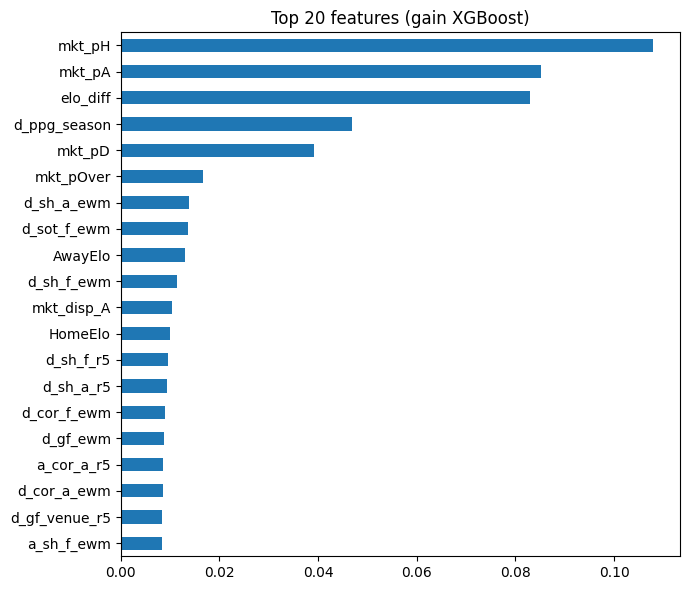

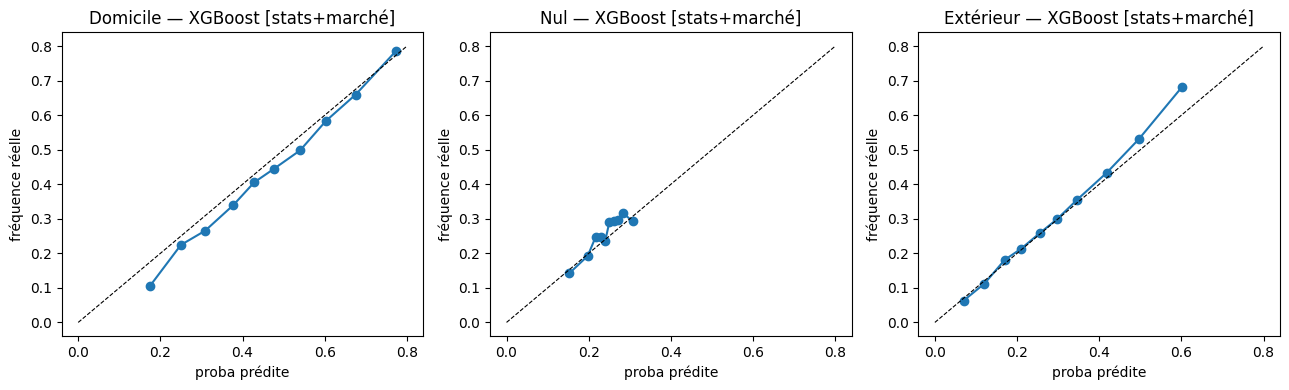

In [9]:
# Importance des variables (XGBoost, stats + marché)
imp = pd.Series(models["XGBoost [stats+marché]"].model.feature_importances_, index=ALL_FEATS).sort_values()
imp.tail(20).plot.barh(figsize=(7, 6), title="Top 20 features (gain XGBoost)"); plt.tight_layout(); plt.show()

# Calibration du meilleur modèle sur le test
best_key = res.drop("Marché Bet365").log_loss.idxmin()
P_best = models[best_key].predict_proba(te)
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for k, lab in enumerate(["Domicile", "Nul", "Extérieur"]):
    b = pd.DataFrame({"p": P_best[:, k], "o": (te.y.values == k)})
    b = b.groupby(pd.qcut(b.p, 10, duplicates="drop")).mean()
    ax[k].plot(b.p, b.o, "o-"); ax[k].plot([0, .8], [0, .8], "k--", lw=.8); ax[k].set_title(f"{lab} — {best_key}")
    ax[k].set_xlabel("proba prédite"); ax[k].set_ylabel("fréquence réelle")
plt.tight_layout(); plt.show()

## 6. Over/Under 2.5 buts
Même logique : classifieur binaire (proba que le total > 2.5) comparé aux probabilités implicites Over/Under.

In [10]:
ou_models, ou_rows = {}, [{"modèle": "Marché Bet365", "accuracy": accuracy_score(te.over25, te.mkt_pOver > .5),
                           "log_loss": log_loss(te.over25, te.mkt_pOver), "roc_auc": roc_auc_score(te.over25, te.mkt_pOver),
                           "brier": brier_score_loss(te.over25, te.mkt_pOver)}]
for fname, feats in [("stats", STAT_FEATS), ("stats+marché", ALL_FEATS)]:
    m = lgb.LGBMClassifier(objective="binary", n_estimators=2000, learning_rate=0.02, num_leaves=15, min_child_samples=100,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=5, verbose=-1, random_state=42)
    m.fit(tr[feats], tr.over25, eval_set=[(va[feats], va.over25)], callbacks=[lgb.early_stopping(100, verbose=False)])
    iso = LogisticRegression().fit(np.log(np.clip(m.predict_proba(va[feats])[:, 1:], 1e-6, 1)), va.over25)
    p = iso.predict_proba(np.log(np.clip(m.predict_proba(te[feats])[:, 1:], 1e-6, 1)))[:, 1]
    ou_models[fname] = (m, iso, feats)
    ou_rows.append({"modèle": f"LightGBM [{fname}]", "accuracy": accuracy_score(te.over25, p > .5), "log_loss": log_loss(te.over25, p),
                    "roc_auc": roc_auc_score(te.over25, p), "brier": brier_score_loss(te.over25, p)})
display(pd.DataFrame(ou_rows).set_index("modèle").round(4))

,accuracy,log_loss,roc_auc,brier
modèle,,,,
Marché Bet365,0.5917,0.6688,0.6183,0.2381
LightGBM [stats],0.5685,0.6795,0.5841,0.2433
LightGBM [stats+marché],0.5928,0.6701,0.6145,0.2387


## 7. Backtest financier — value betting
On parie sur une issue seulement si **valeur = p_modèle × cote − 1 > seuil**, au plus un pari par match (la plus grande valeur).
* **ROI** = (gains nets) / (total misé) · **Rendement bankroll** = (bankroll finale − initiale) / initiale
* Cotes utilisées : Bet365 (réalistes). Les « meilleures cotes » (Max) sont optimistes : elles supposent des comptes chez ~17 bookmakers sans limitation.

In [11]:
ODDS_COLS = ["OddHome", "OddDraw", "OddAway"]

def select_bets(D, P, odds_cols=ODDS_COLS, threshold=0.05, pmin=0.0, max_odds=10):
    O = D[odds_cols].values
    V = P * O - 1
    V[(O > max_odds) | (P < pmin)] = -np.inf
    k = V.argmax(1); v = V[np.arange(len(D)), k]
    sel = v > threshold
    B = pd.DataFrame({"date": D.MatchDate.values, "match": D.HomeTeam.values + " - " + D.AwayTeam.values,
                      "pick": np.array(["1", "X", "2"])[k], "p": P[np.arange(len(D)), k], "odds": O[np.arange(len(D)), k],
                      "value": v, "won": (D.y.values == k)})[sel]
    return B.sort_values("date").reset_index(drop=True)

FIB = [1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987]

def run_staking(B, method="flat", bank0=100.0, unit=1.0, kelly_frac=0.25, cap=0.05):
    bank, fib_i, hist, staked = bank0, 0, [bank0], 0.0
    for p, o, w in zip(B.p, B.odds, B.won):
        if method == "flat":
            s = unit
        elif method == "kelly":                            # Kelly fractionné : f* = (p·o − 1)/(o − 1)
            s = bank * min(cap, kelly_frac * max(0, (p * o - 1) / (o - 1)))
        elif method == "fibonacci":                        # progression après perte, recule de 2 crans après gain
            s = unit * FIB[min(fib_i, len(FIB) - 1)]
        s = min(s, bank)
        if s <= 0: hist.append(bank); continue
        staked += s
        bank += s * (o - 1) if w else -s
        if method == "fibonacci":
            fib_i = max(fib_i - 2, 0) if w else fib_i + 1
        hist.append(bank)
        if bank <= 0.01: break
    h = np.array(hist)
    return {"paris": len(h) - 1, "misé": staked, "profit": h[-1] - bank0, "ROI_%": 100 * (h[-1] - bank0) / max(staked, 1e-9),
            "bankroll_finale": h[-1], "drawdown_max_%": 100 * np.max(1 - h / np.maximum.accumulate(h)), "courbe": h}

def backtest_table(P, D, label, **kw):
    B = select_bets(D, P, **kw)
    out = []
    for m in ["flat", "kelly", "fibonacci"]:
        r = run_staking(B, m); r.pop("courbe")
        out.append({"modèle": label, "mise": m, **{k: round(v, 2) if isinstance(v, float) else v for k, v in r.items()}})
    return out, B

rows = []
for key in ["LogReg [stats]", "XGBoost [stats]", "LightGBM [stats+marché]", best_key]:
    r, _ = backtest_table(models[key].predict_proba(te), te, key, threshold=0.05)
    rows += r
bt = pd.DataFrame(rows).drop_duplicates(["modèle", "mise"])
display(bt)

,modèle,mise,paris,misé,profit,ROI_%,bankroll_finale,drawdown_max_%
0,LogReg [stats],flat,612,611.87,-100.00,-16.34,0.00,100.00
1,LogReg [stats],kelly,3191,924.57,-99.99,-10.81,0.01,99.99
2,LogReg [stats],fibonacci,20,156.86,-100.00,-63.75,0.00,100.00
3,XGBoost [stats],flat,565,563.44,-100.00,-17.75,0.00,100.00
4,XGBoost [stats],kelly,2974,743.31,-99.98,-13.45,0.02,99.98
5,XGBoost [stats],fibonacci,26,461.80,-100.00,-21.65,0.00,100.00
6,LightGBM [stats+marché],flat,744,743.11,-100.00,-13.46,0.00,100.00
7,LightGBM [stats+marché],kelly,1528,1313.27,-62.68,-4.77,37.32,83.48
8,LightGBM [stats+marché],fibonacci,47,218.43,-100.00,-45.78,0.00,100.00
9,XGBoost [stats+marché],flat,527,526.78,-100.00,-18.98,0.00,100.00


,seuil_valeur,paris,cote_moy,taux_réussite,ROI_%,IC95_bas,IC95_haut
0,0.00,3354,3.09,0.392,-7.53,-12.0,-3.0
1,0.02,2240,3.36,0.365,-9.22,-15.1,-3.3
2,0.05,1085,4.08,0.298,-13.11,-22.5,-3.2
3,0.10,391,5.74,0.161,-27.86,-45.8,-7.4
4,0.15,196,6.74,0.128,-24.13,-51.2,4.8
5,0.20,109,7.21,0.128,-16.71,-57.4,28.6


Bet365                         seuil 2 %, cotes ≤ 4 : 1595 paris, ROI -3.24%
Meilleures cotes (optimiste)   seuil 2 %, cotes ≤ 4 : 3060 paris, ROI -1.96%
Si l'IC à 95 % contient 0, le ROI observé n'est pas distinguable de la chance.


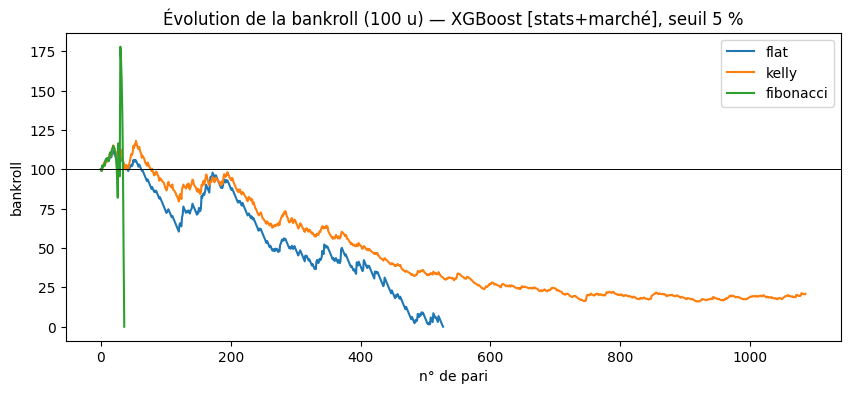

In [12]:
# Sensibilité au seuil de valeur + intervalle de confiance bootstrap du ROI (mise fixe)
def boot_ci(B, n=2000):
    pnl = np.where(B.won, B.odds - 1, -1.0)
    s = RNG.choice(pnl, (n, len(pnl)), replace=True).mean(1) * 100
    return np.percentile(s, [2.5, 97.5])

P_bt = models[best_key].predict_proba(te)
sens = []
for th in [0.0, 0.02, 0.05, 0.10, 0.15, 0.20]:
    B = select_bets(te, P_bt, threshold=th)
    if len(B) < 30: continue
    lo, hi = boot_ci(B)
    sens.append({"seuil_valeur": th, "paris": len(B), "cote_moy": B.odds.mean().round(2), "taux_réussite": B.won.mean().round(3),
                 "ROI_%": round(100 * (np.where(B.won, B.odds - 1, -1).mean()), 2), "IC95_bas": round(lo, 1), "IC95_haut": round(hi, 1)})
display(pd.DataFrame(sens))
for lab, cols in [("Bet365", ODDS_COLS), ("Meilleures cotes (optimiste)", ["MaxHome", "MaxDraw", "MaxAway"])]:
    Bx = select_bets(te.dropna(subset=cols), P_bt[te[cols].notna().all(1).values], odds_cols=cols, threshold=0.02, max_odds=4)
    print(f"{lab:30s} seuil 2 %, cotes ≤ 4 : {len(Bx)} paris, ROI {100*np.where(Bx.won, Bx.odds-1, -1).mean():+.2f}%")
print("Si l'IC à 95 % contient 0, le ROI observé n'est pas distinguable de la chance.")

B = select_bets(te, P_bt, threshold=0.05)
plt.figure(figsize=(10, 4))
for m in ["flat", "kelly", "fibonacci"]:
    plt.plot(run_staking(B, m)["courbe"], label=m)
plt.axhline(100, color="k", lw=.7); plt.legend(); plt.title(f"Évolution de la bankroll (100 u) — {best_key}, seuil 5 %")
plt.xlabel("n° de pari"); plt.ylabel("bankroll"); plt.show()

## 8. Fibonacci vs mise fixe vs Kelly — simulation Monte-Carlo
Question : la suite de Fibonacci améliore-t-elle la rentabilité ? On simule 5 000 saisons de 300 paris à cote 3.20, dans deux mondes : pari **perdant** (vraie proba 0.30 → espérance −4 %) et pari **gagnant** (vraie proba 0.33 → espérance +5.6 %).

In [13]:
def simulate(p, odds, method, n_bets=300, n_sims=5000, bank0=100.0):
    finals, ruins, stakes = [], 0, []
    for _ in range(n_sims):
        wins = RNG.random(n_bets) < p
        B = pd.DataFrame({"p": p, "odds": odds, "won": wins})
        r = run_staking(B, method, bank0=bank0)
        finals.append(r["bankroll_finale"]); stakes.append(r["misé"]); ruins += r["bankroll_finale"] < 1
    finals, stakes = np.array(finals), np.array(stakes)
    return {"méthode": method, "bankroll_médiane": np.median(finals).round(1), "bankroll_moy": finals.mean().round(1),
            "ROI_moyen_%": (100 * (finals - bank0).sum() / stakes.sum()).round(2) if stakes.sum() > 0 else 0.0,
            "mise_totale_moy": stakes.mean().round(1), "P(ruine)_%": 100 * ruins / n_sims,
            "P(perte)_%": (100 * (finals < bank0).mean()).round(1)}

sim = []
for label, p in [("EV négative (p=0.30)", 0.30), ("EV positive (p=0.33)", 0.33)]:
    for m in ["flat", "kelly", "fibonacci"]:
        sim.append({"scénario": label, **simulate(p, 3.2, m, n_sims=2000)})
display(pd.DataFrame(sim))
print("→ Kelly avec EV négative : f* < 0 → aucune mise (c'est voulu : Kelly refuse les paris sans avantage).")
print("→ Le ROI par unité misée est fixé par l'avantage (p × cote − 1), pas par la progression des mises.")
print("→ Fibonacci augmente les mises après les pertes : même espérance par euro misé, mais risque de ruine bien plus élevé.")

,scénario,méthode,bankroll_médiane,bankroll_moy,ROI_moyen_%,mise_totale_moy,P(ruine)_%,P(perte)_%
0,EV négative (p=0.30),flat,88.0,88.0,-4.01,300.0,0.0,67.7
1,EV négative (p=0.30),kelly,100.0,100.0,0.00,0.0,0.0,0.0
2,EV négative (p=0.30),fibonacci,0.0,36.0,-6.00,1066.9,99.4,99.4
3,EV positive (p=0.33),flat,116.8,116.4,5.46,300.0,0.0,26.8
4,EV positive (p=0.33),kelly,109.8,111.3,5.58,201.6,0.0,29.3
5,EV positive (p=0.33),fibonacci,0.0,206.1,5.58,1899.7,96.0,96.0


→ Kelly avec EV négative : f* < 0 → aucune mise (c'est voulu : Kelly refuse les paris sans avantage).
→ Le ROI par unité misée est fixé par l'avantage (p × cote − 1), pas par la progression des mises.
→ Fibonacci augmente les mises après les pertes : même espérance par euro misé, mais risque de ruine bien plus élevé.


## 9. Prédire les prochains matchs
Renseignez les affiches et les cotes du moment. Les features sont recalculées avec le même pipeline (donc sans fuite) à partir de l'historique le plus récent.

In [14]:
def predict_fixtures(fixtures, model_key=best_key):
    """fixtures : liste de dicts {Division, date, home, away, odds_1, odds_x, odds_2, odds_over, odds_under}"""
    hist = df.copy()
    last_elo = pd.concat([hist[["MatchDate", "HomeTeam", "HomeElo"]].set_axis(["d", "t", "elo"], axis=1),
                          hist[["MatchDate", "AwayTeam", "AwayElo"]].set_axis(["d", "t", "elo"], axis=1)]).sort_values("d").groupby("t").elo.last()
    new = []
    for i, f in enumerate(fixtures):
        dt = pd.Timestamp(f["date"])
        new.append({"Division": f["Division"], "MatchDate": dt, "HomeTeam": f["home"], "AwayTeam": f["away"],
                    "Season": dt.year if dt.month >= 7 else dt.year - 1, "match_id": hist.match_id.max() + 1 + i,
                    "HomeElo": last_elo.get(f["home"], np.nan), "AwayElo": last_elo.get(f["away"], np.nan),
                    "OddHome": f["odds_1"], "OddDraw": f["odds_x"], "OddAway": f["odds_2"],
                    "MaxHome": f["odds_1"], "MaxAway": f["odds_2"], "Over25": f.get("odds_over", np.nan), "Under25": f.get("odds_under", np.nan)})
    full = pd.concat([hist, pd.DataFrame(new)], ignore_index=True)
    Xf = build_features(full)
    Xf = Xf[Xf.match_id.isin([n["match_id"] for n in new])]
    P = models[model_key].predict_proba(Xf)
    out = Xf[["HomeTeam", "AwayTeam", "OddHome", "OddDraw", "OddAway"]].copy()
    out[["P1", "PX", "P2"]] = P.round(3)
    out[["mkt_1", "mkt_X", "mkt_2"]] = Xf[["mkt_pH", "mkt_pD", "mkt_pA"]].values.round(3)
    V = P * Xf[ODDS_COLS].values - 1
    out["meilleure_valeur"] = np.array(["1", "X", "2"])[V.argmax(1)]
    out["valeur_%"] = (100 * V.max(1)).round(1)
    out["kelly_25%_de_bankroll_%"] = (100 * np.clip(0.25 * V.max(1) / (Xf[ODDS_COLS].values[np.arange(len(V)), V.argmax(1)] - 1), 0, 0.05)).round(2)
    return out

# Exemple (noms d'équipes = ceux du dataset ; cotes fictives à remplacer par les vraies)
print(sorted(df[df.Division == "E0"].HomeTeam.unique())[-10:])
predict_fixtures([
    {"Division": "E0", "date": "2026-10-03", "home": "Arsenal", "away": "Liverpool", "odds_1": 2.30, "odds_x": 3.50, "odds_2": 3.10, "odds_over": 1.75, "odds_under": 2.10},
    {"Division": "SP1", "date": "2026-10-04", "home": "Barcelona", "away": "Sevilla", "odds_1": 1.40, "odds_x": 5.00, "odds_2": 7.50, "odds_over": 1.50, "odds_under": 2.60},
])

['Southampton', 'Stoke', 'Sunderland', 'Swansea', 'Tottenham', 'Watford', 'West Brom', 'West Ham', 'Wigan', 'Wolves']


,HomeTeam,AwayTeam,OddHome,OddDraw,OddAway,P1,PX,P2,mkt_1,mkt_X,mkt_2,meilleure_valeur,valeur_%,kelly_25%_de_bankroll_%
37741,Arsenal,Liverpool,2.3,3.5,3.1,0.446,0.252,0.303,0.417,0.274,0.309,1,2.5,0.48
37742,Barcelona,Sevilla,1.4,5.0,7.5,0.726,0.195,0.078,0.682,0.191,0.127,1,1.7,1.05


## 10. (Optionnel) Cotes de clôture et CLV avec les CSV bruts de football-data.co.uk
Les CSV officiels (mis à jour 2×/semaine) contiennent les cotes Pinnacle d'ouverture (`PSH/PSD/PSA`) et de **clôture** (`PSCH/PSCD/PSCA`) depuis 2019/20.
**CLV** (Closing Line Value) = cote prise / cote juste de clôture − 1. Un CLV moyen > 0 sur des centaines de paris est le meilleur signe d'un vrai avantage, bien avant que le ROI ne soit significatif.

In [15]:
def load_fd(league="E0", season="2526"):
    url = f"https://www.football-data.co.uk/mmz4281/{season}/{league}.csv"
    d = pd.read_csv(url, encoding="latin-1")
    d["Date"] = pd.to_datetime(d.Date, dayfirst=True)
    return d

def clv(odds_taken, close_h, close_d, close_a, pick):
    """pick ∈ {0,1,2}. Cote juste de clôture = 1 / proba dé-margée Pinnacle à la clôture."""
    P, _ = implied(np.asarray(close_h), np.asarray(close_d), np.asarray(close_a))
    fair = 1 / P[np.arange(len(P)), np.asarray(pick)]
    return np.asarray(odds_taken) / fair - 1

try:
    fd = load_fd("E0", "2526")
    fd = fd.dropna(subset=["PSH", "PSCH"])
    # Exemple : CLV d'une stratégie « toujours le nul à la cote Pinnacle d'ouverture »
    c = clv(fd.PSD, fd.PSCH, fd.PSCD, fd.PSCA, np.ones(len(fd), int))
    print(f"{len(fd)} matchs | CLV moyen 'nul à l'ouverture' : {100*c.mean():+.2f}%")
except Exception as ex:
    print("football-data.co.uk inaccessible depuis ce runtime :", ex)

football-data.co.uk inaccessible depuis ce runtime : <urlopen error Tunnel connection failed: 403 Forbidden>


## 11. Pistes d'amélioration
* **Cotes de clôture** (Pinnacle `PSCH/PSCD/PSCA` dans les CSV de football-data.co.uk) pour mesurer le **CLV** : battre la cote de clôture est le meilleur indicateur précoce d'un vrai avantage.
* **xG** (Understat via `soccerdata`) : remplacer buts/tirs par des moyennes mobiles d'xG pour/contre.
* **Modèle de Poisson / Dixon-Coles** pour les marchés de buts (Over/Under, score exact).
* **Walk-forward** : ré-entraîner chaque saison (ou chaque mois) et empiler les prédictions hors échantillon.
* **Compositions et blessures** (API-Football) : ajouter l'absence des joueurs clés, 1 h avant le match.